# RNR1 analysis
February 8, 2024


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Let's test this scaling by looking at a gene's deconvolution
# We will look at CLB2 and see how the scaling affects the read counts of the raw data

from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
    load_yl_replicate2_rg1_alpha_vst_config
from cc_src.chromatin_model import ChromatinModel

config1 = load_yl_replicate1_rg1_alpha_vst_config()
config2 = load_yl_replicate2_rg1_alpha_vst_config()

gene_name = 'RNR1'
chrom1_model = ChromatinModel(config1)
chrom1_model.load_mnase_gene(gene_name, replicate=1)

chrom2_model = ChromatinModel(config2)
chrom2_model.load_mnase_gene(gene_name, replicate=2)

Loading MNase reads for RNR1...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the unflattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the unflattened grid to be deconvolved is: (16, 27)
Loading MNase reads for RNR1...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the unflattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the unflattened grid to be deconvolved is: (15, 27)


In [3]:
from src.model import Model
ge_model1 = Model(config1, gene_name)
ge_model1.deconvolve_find_optimal_gamma()

In [4]:
ge_model2 = Model(config2, gene_name)
ge_model2.deconvolve_find_optimal_gamma()

In [16]:
#chrom1_model.deconvolve_find_optimal()
chrom1_model.gamma = 0.001
chrom1_model.deconvolve()

Deconvolved in : 00:00:43.86
The fitting norm is 0.67, the smoothing norm is: 45.88


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [17]:
#chrom1_model.deconvolve_find_optimal()
chrom1_model.gamma = 0.001
chrom2_model.deconvolve()

Deconvolved in : 00:00:11.54
The fitting norm is 0.81, the smoothing norm is: 9.43


In [ ]:
chrom2_model.deconvolve_find_optimal()

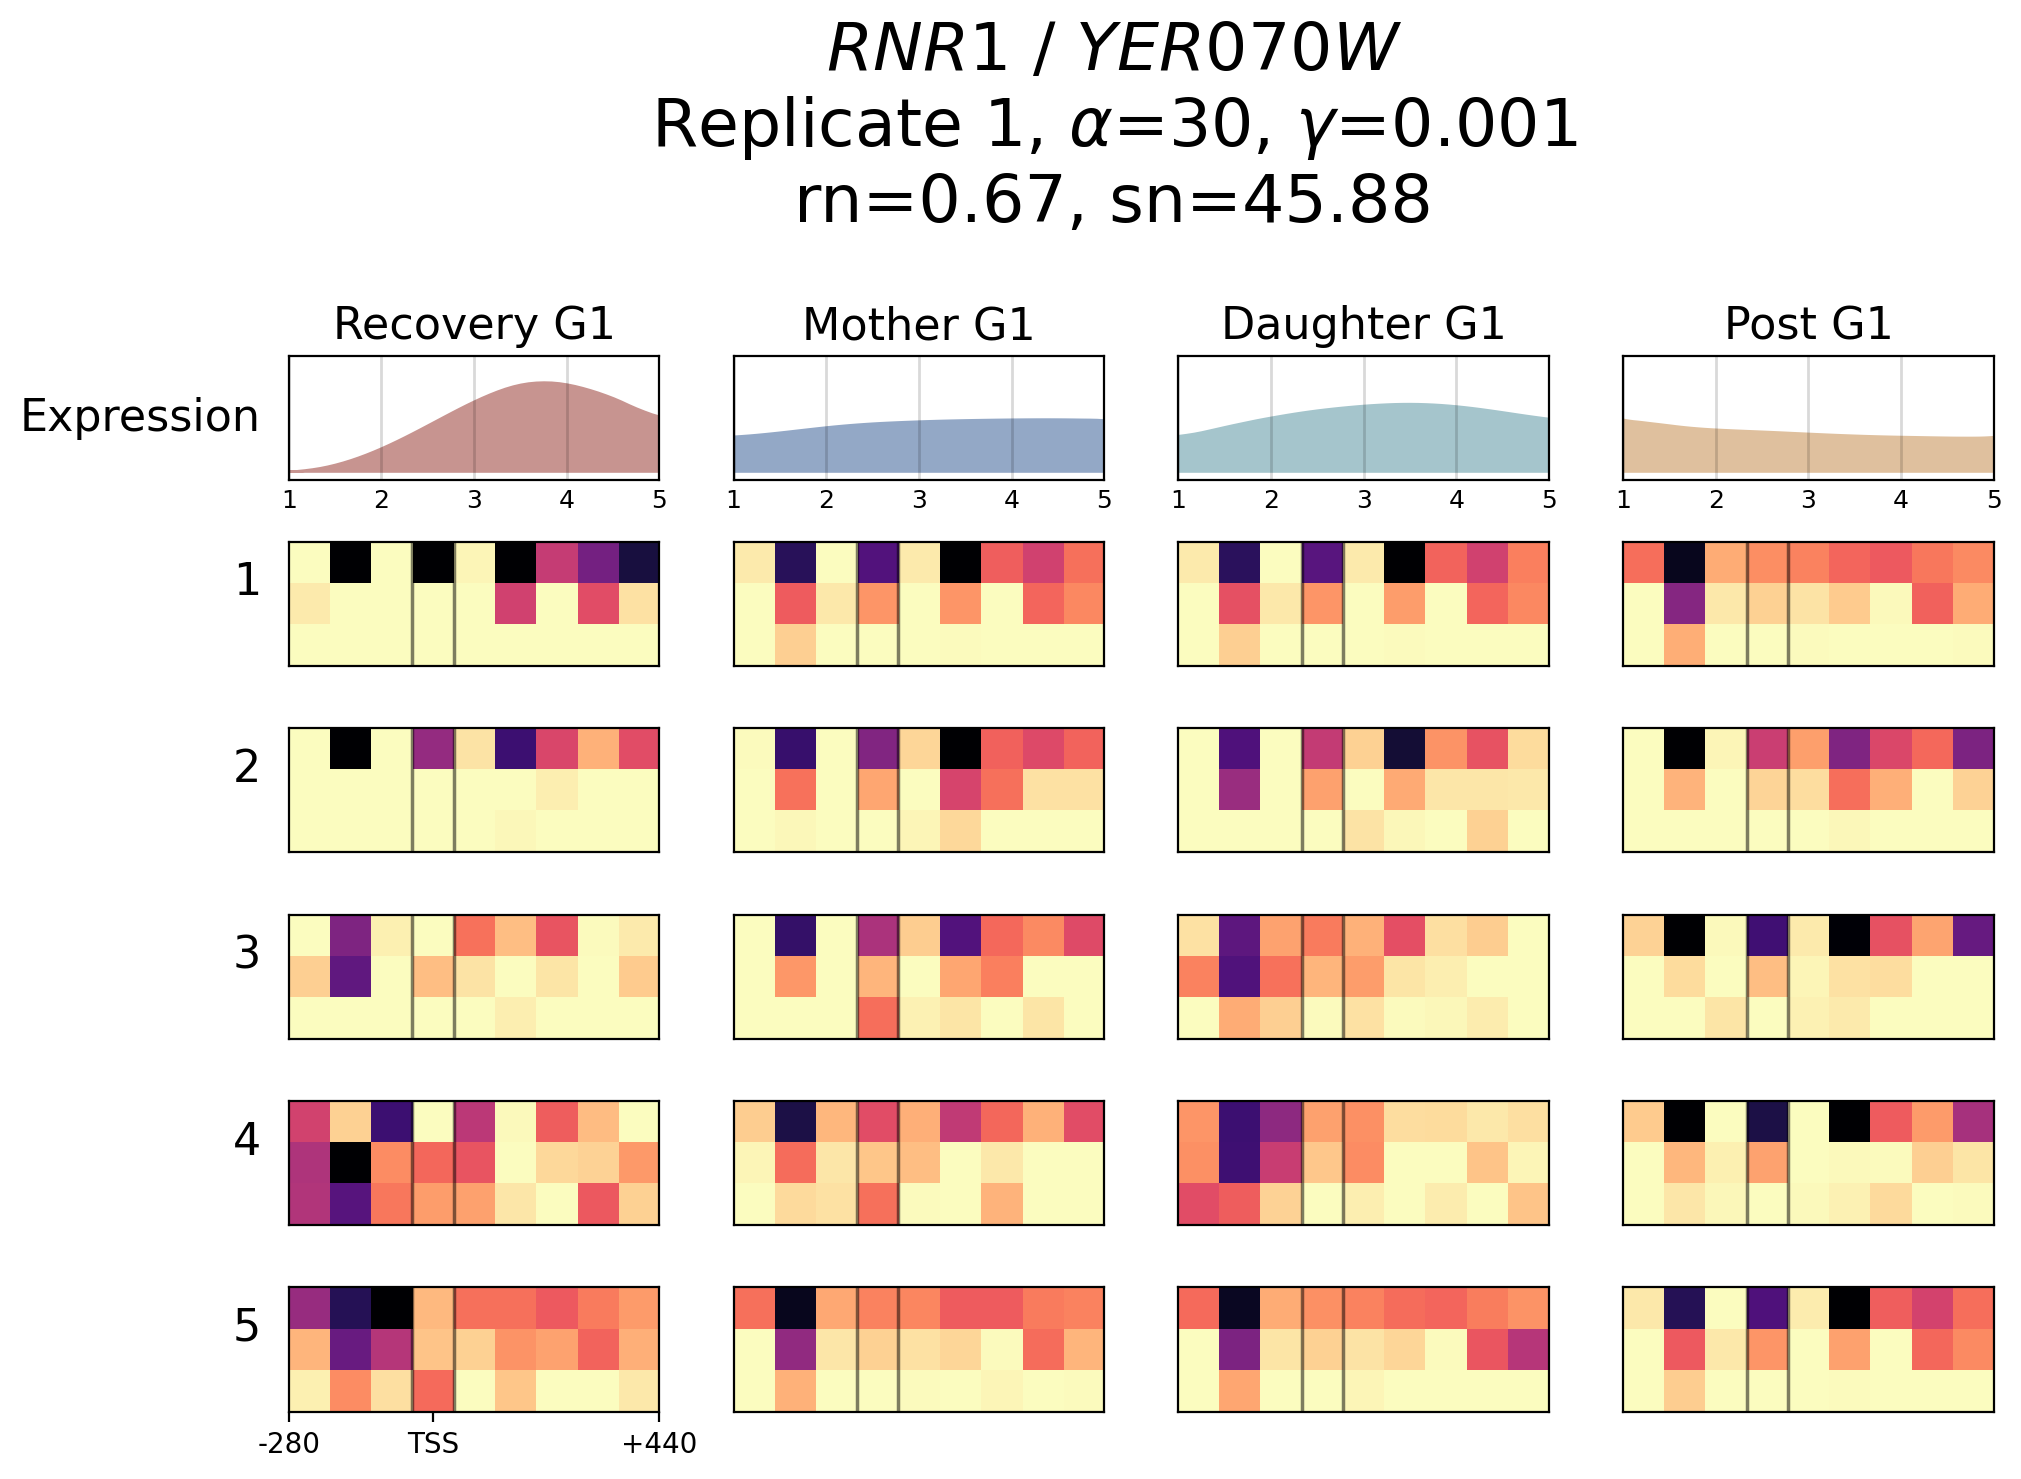

In [18]:
chrom1_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model1)

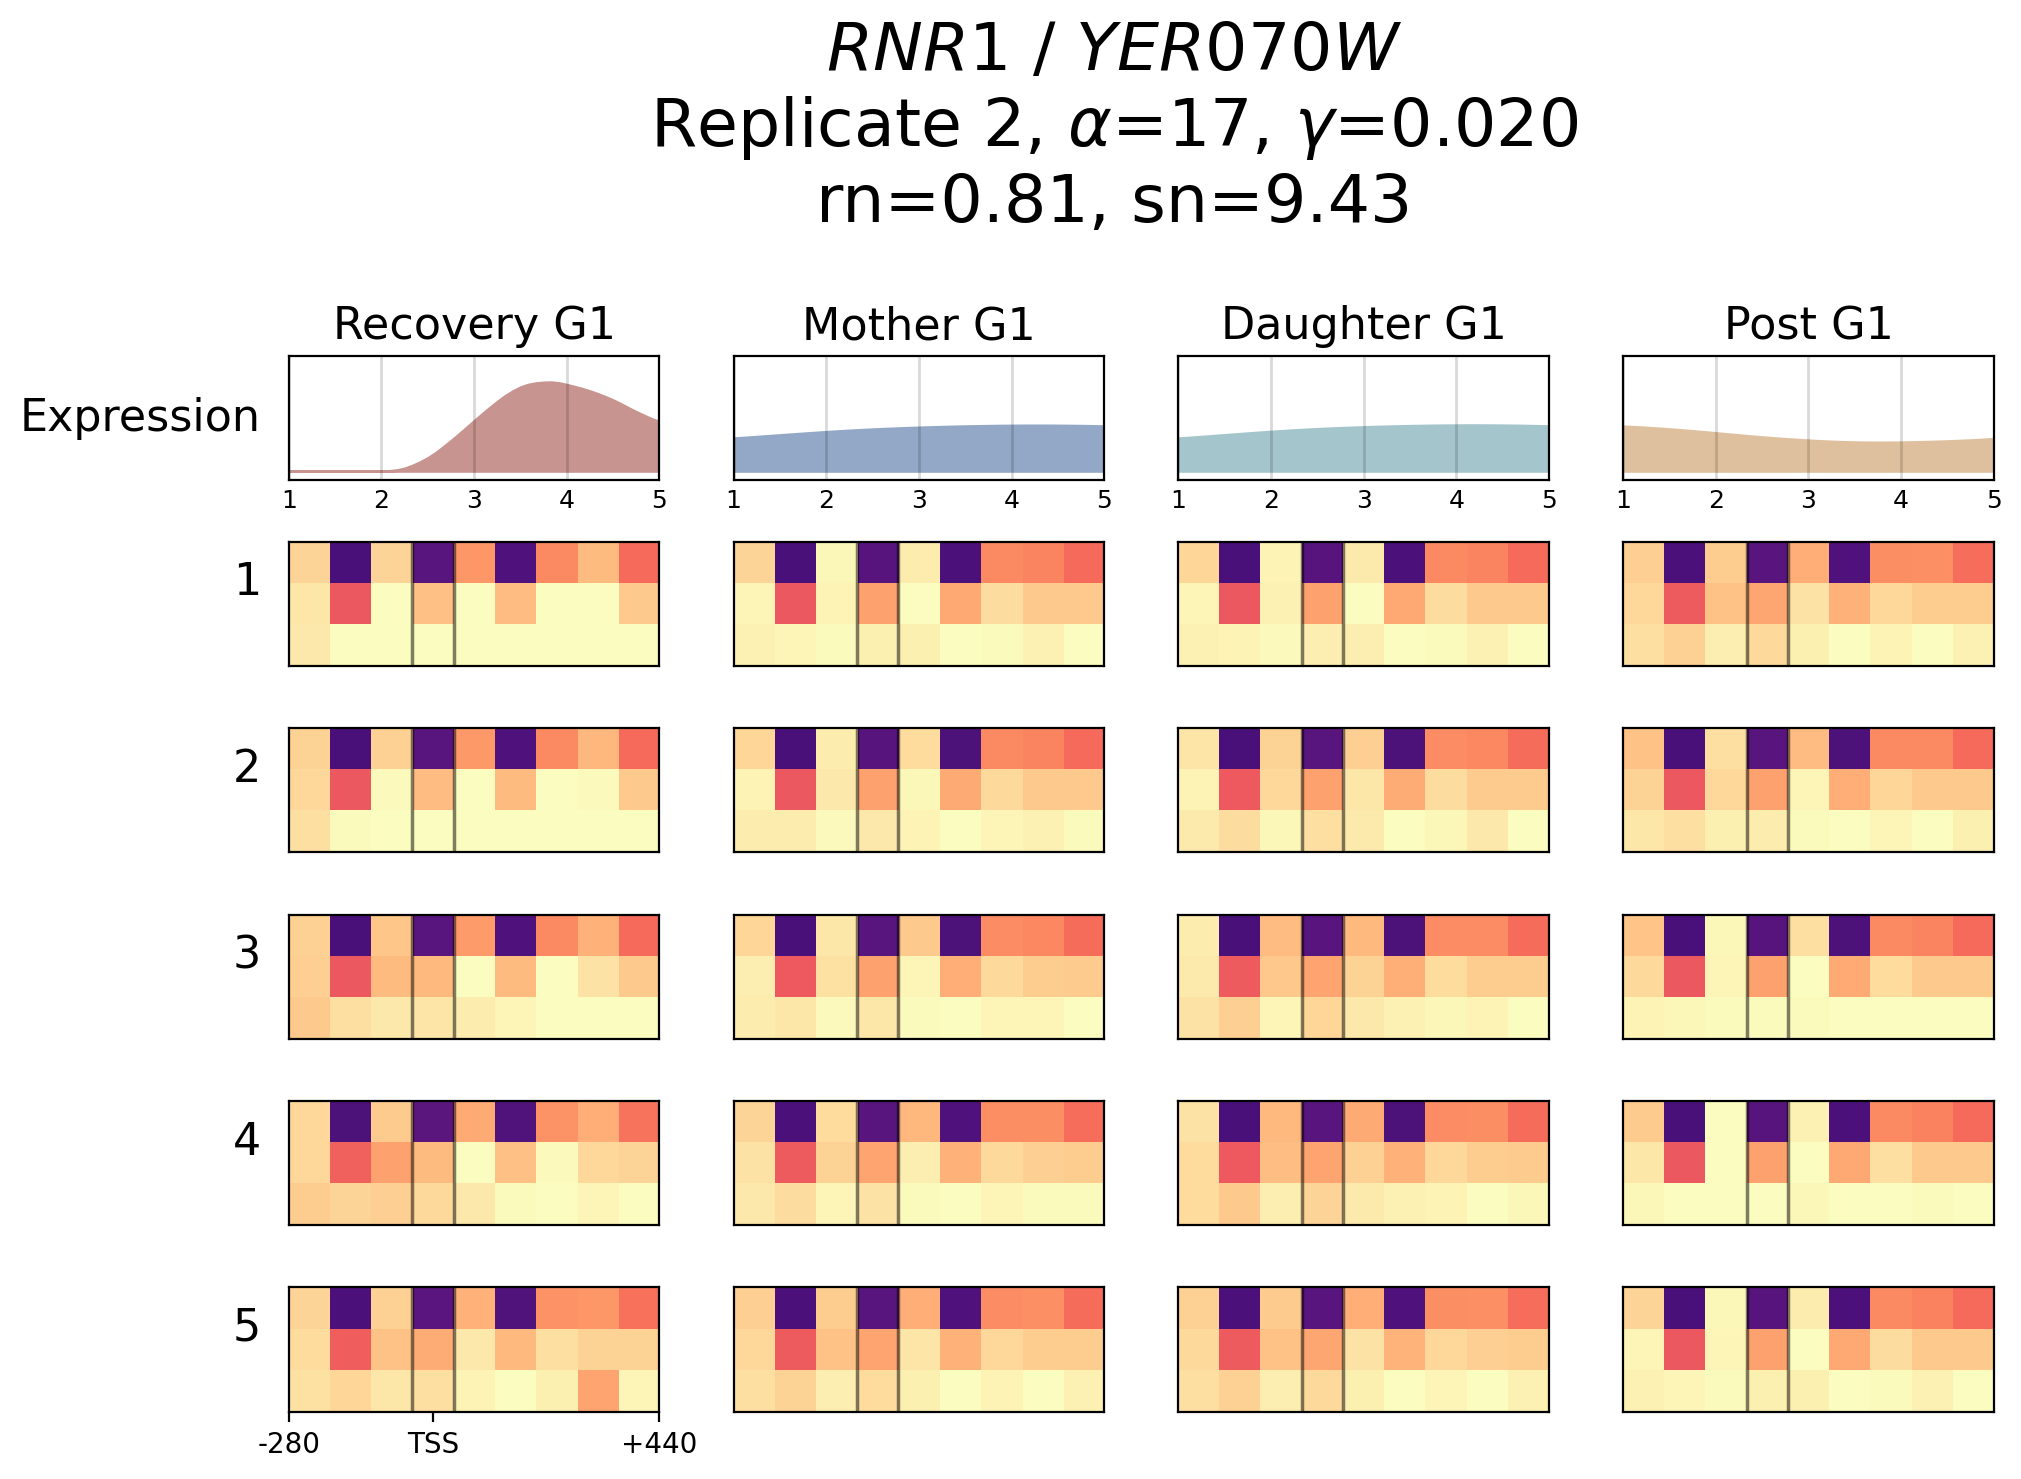

In [19]:
chrom2_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model2)

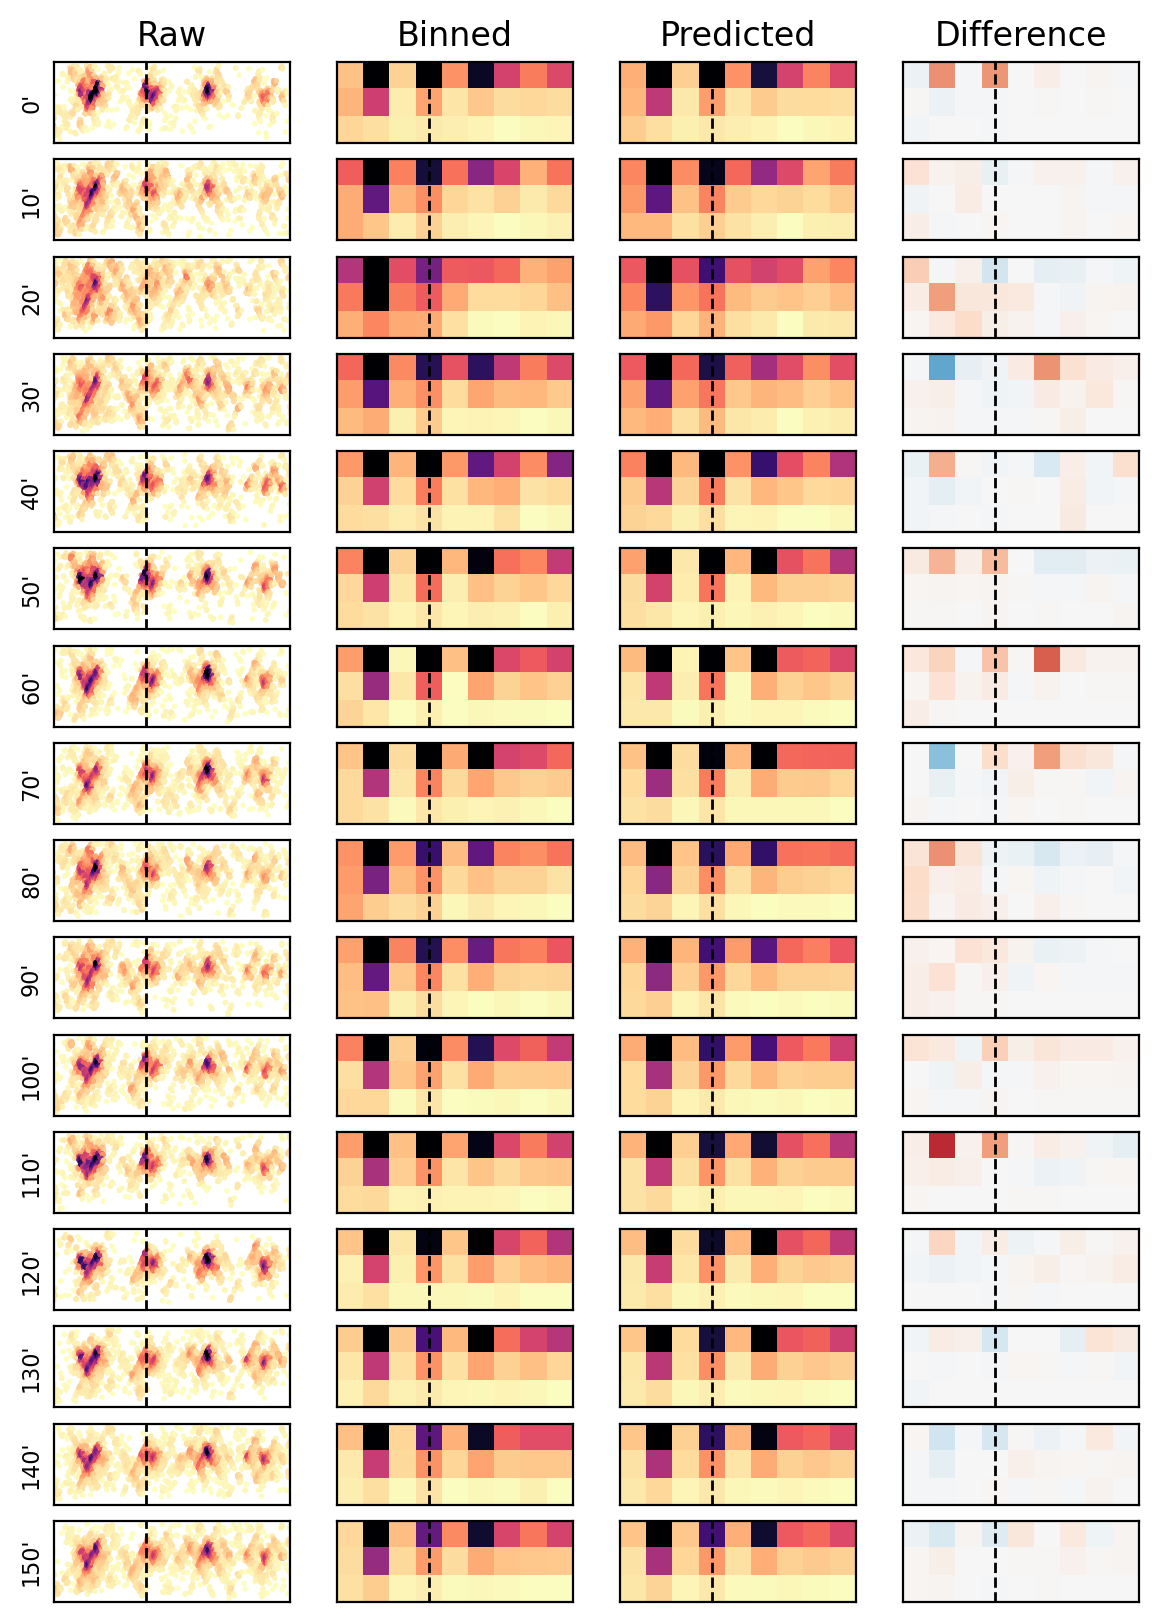

In [20]:
chrom1_model.plot_prediction_comparison()

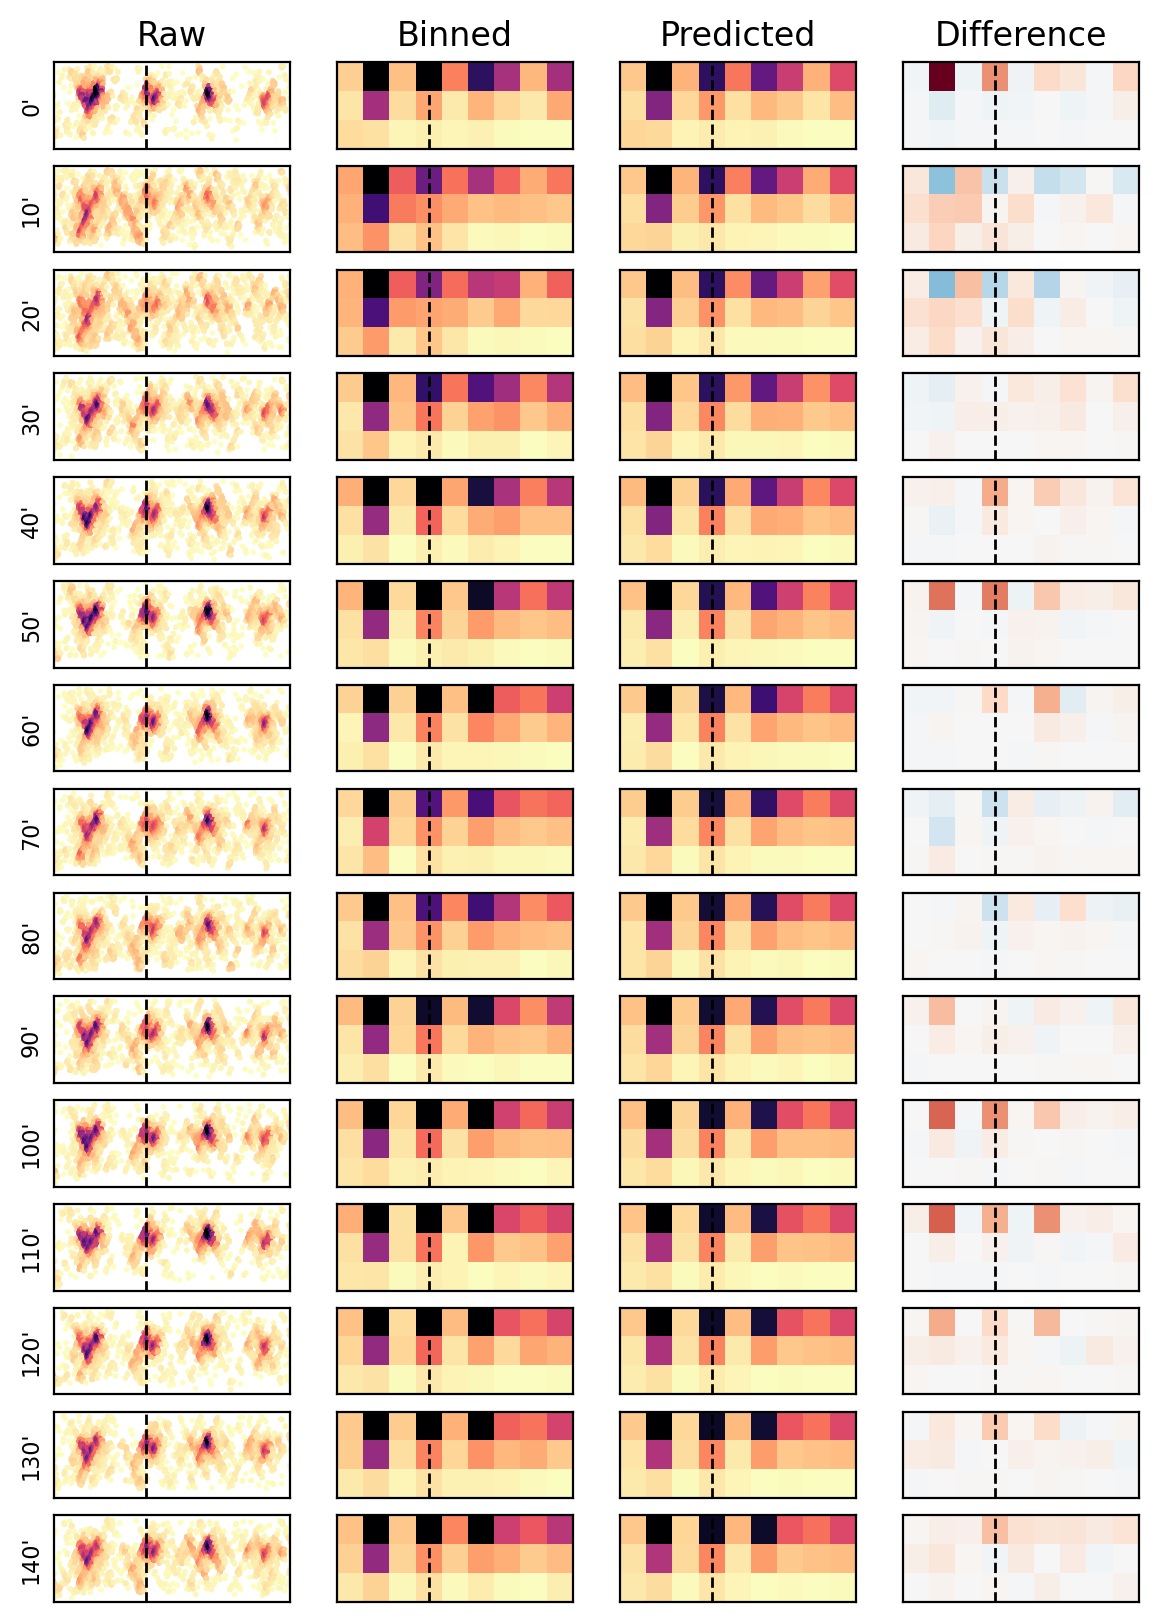

In [21]:
chrom2_model.plot_prediction_comparison()